### BHSD (Brain Hemorrhage Segmentation Database) Analysis

The [BHSD](https://www.kaggle.com/datasets/stevezeyuzhang/bhsd-dataset/data) is a dataset sourced from the 2019 RSNA ICH Detection Grand Challenge.

It contains 192 volumes with *pixel-level* hemorrhage type information. In the corresponding ground truth masks, pixel value 0 corresponds to background, while 1-5 correspond to EDH, IPH, IVH, SAH, and SDH.

While there is no age information (or any other demographics), it is the largest dataset with pixel level hemorrhage type information that I have found. 

### Dataframe creation

In the below chunk, the data are loaded and the following information is aggregated:
* Hemorrhage type
* Hemorrhage volume
* Mean and median HU within the hemorrhage boundary
* Image dimension information (for calculating volume)
* Number of slices (to calculate vertical spread of hemorrhage)

In [7]:
from pathlib import *
import nibabel as nib
import numpy as np
import pandas as pd
import os
import sys

save_opt = False

labels = ["bkg", "EDH", "IPH", "IVH", "SAH", "SDH"] # 0, 1, 2, 3, 4, 5


dataset_path = Path('/home/jayse.weaver/RSNA_BHSD/') # can move to public location if necessary
img_dir = dataset_path / "images"
truth_dir = dataset_path / "ground_truths"

row_idx = 0

# initialize empty dataframe
df = pd.DataFrame(columns=['Data_ID', 'Type', 'Volume_[mL]', 'Mean_HU', 'Median_HU', 'dx', 'dy', 'dz', 'num_slices', 'z_dist'])

label_names = sorted(os.listdir(img_dir))
for idx, file in enumerate(label_names):
    img = nib.load(img_dir / file)
    [dx, dy, dz] = img.header['pixdim'][1:4]
    image = img.get_fdata()

    mask = nib.load(truth_dir / file).get_fdata()

    for label_idx in range(1, len(labels)): # skip background
        hemorrhage_volume = (len(np.argwhere(mask == label_idx)))*((dx*dy*dz)/1000)

        if hemorrhage_volume != 0:
            hemorrhage_mask = np.where(mask == label_idx, 1, 0)
            num_slices = 0
            for slice_idx in range(hemorrhage_mask.shape[2]):
                slice = hemorrhage_mask[:, :, slice_idx]
                if np.any(slice): # check if hemorrhage
                    num_slices += 1

            z_dist = num_slices * dz

            # calculate mean and median HU
            lesion_only = np.multiply(image, hemorrhage_mask)

            lesion_only[lesion_only < -500] = 0

            mean_HU = np.mean(lesion_only[np.nonzero(hemorrhage_mask)])
            median_HU = np.median(lesion_only[np.nonzero(hemorrhage_mask)])

            df.loc[row_idx] = [str(file), labels[label_idx], hemorrhage_volume, mean_HU, median_HU, dx, dy, dz, num_slices, z_dist]
            row_idx += 1

print(df)

if save_opt:
    df.to_csv('RSNA_BHSD.csv')

                              Data_ID Type  Volume_[mL]    Mean_HU  Median_HU  \
0    ID_0237f3c9_ID_40015688b9.nii.gz  IPH     7.607403  60.248260       63.0   
1    ID_0237f3c9_ID_40015688b9.nii.gz  IVH     3.454472  48.978467       48.0   
2    ID_029ebbea_ID_563afa0901.nii.gz  IPH     7.652559  53.687836       55.0   
3    ID_029ebbea_ID_563afa0901.nii.gz  SDH    33.544232  68.355500       71.0   
4    ID_02b882cc_ID_a4892e60ae.nii.gz  IPH    45.146500  54.583556       54.0   
..                                ...  ...          ...        ...        ...   
428  ID_faa3c13d_ID_c31106b8dc.nii.gz  SDH     2.867018  39.005701       39.0   
429  ID_fb6d0135_ID_497840f16e.nii.gz  IVH     1.015713  46.148101       46.0   
430  ID_fb6d0135_ID_497840f16e.nii.gz  SAH     9.935984  46.803442       45.0   
431  ID_fb6d0135_ID_497840f16e.nii.gz  SDH     1.542855  55.245000       56.0   
432  ID_fcbe7eda_ID_5726e1c630.nii.gz  SAH     1.457930  47.225675       47.0   

           dx        dy    

<Axes: xlabel='Volume_[mL]', ylabel='Mean_HU'>

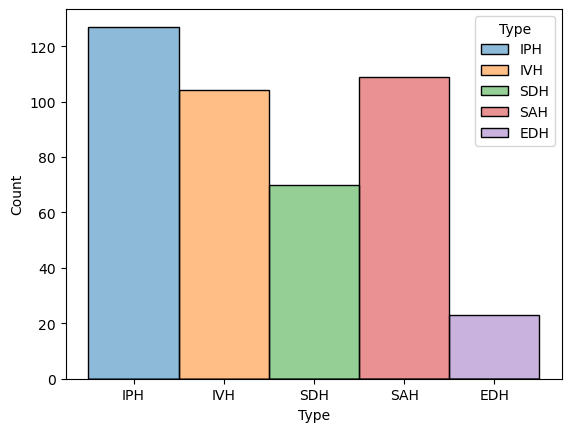

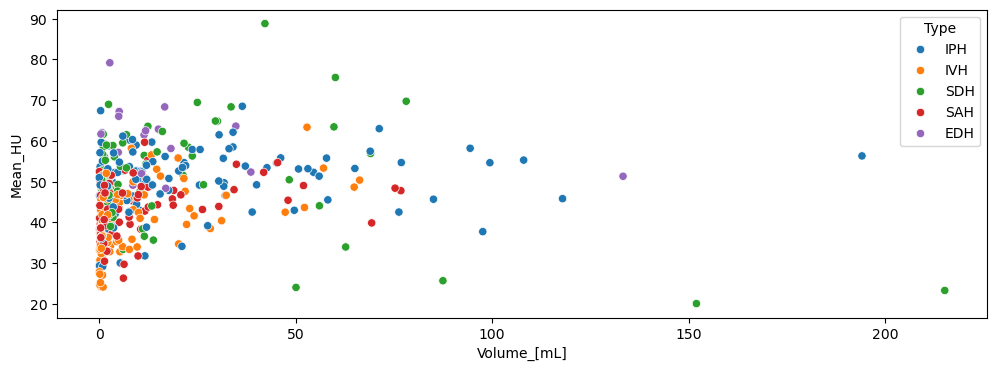

In [8]:
# Let's plot!
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(data=df, x="Type", hue="Type", legend=True)

plt.figure(figsize=(12, 4))
sns.scatterplot(data=df, x="Volume_[mL]", y="Mean_HU", hue="Type", legend=True)

### The dataset has a nice distribution of IPH, IVH, SDH, and SAD, but an underwhelming number of EDH.

However, this may be expected as SDH is more common than EDH in both severe and mild TBI (https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7912597/)

Next, let's look at all of the volume and HU data together in a joint grid with kernel density estimate plots on the axes:

[10.0,
 100.0,
 0.0,
 250.0,
 10.0,
 100.0,
 0.0,
 250.0,
 10.0,
 100.0,
 0.0,
 250.0,
 10.0,
 100.0,
 0.0,
 250.0,
 10.0,
 100.0,
 0.0,
 250.0]

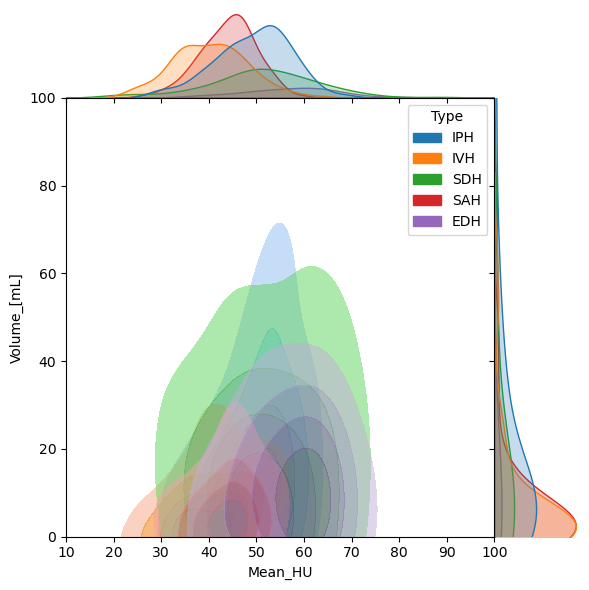

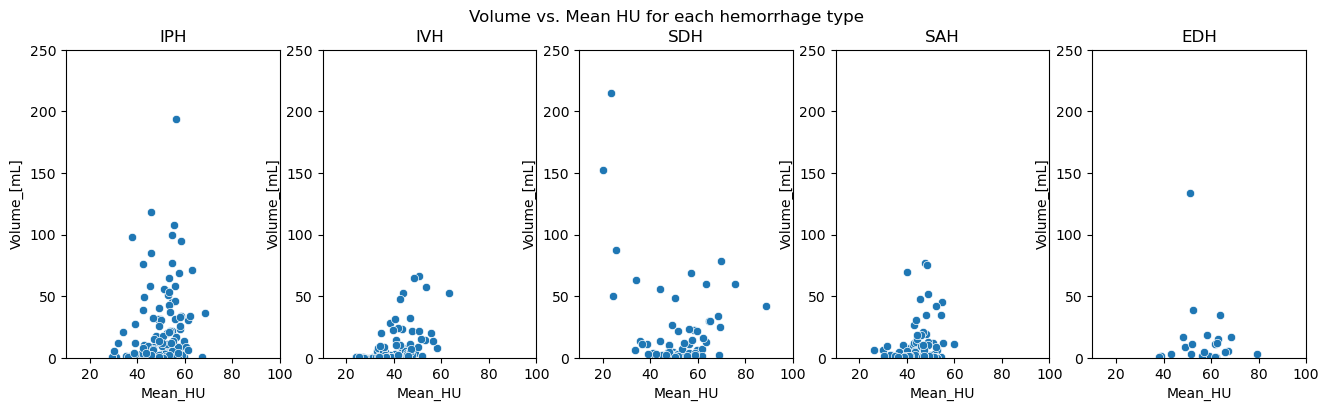

In [22]:
g = sns.JointGrid(data=df, x="Mean_HU", y="Volume_[mL]", hue="Type", space=0, xlim=(10,100), ylim=(0, 100))
g.plot_joint(sns.kdeplot, alpha=0.5, fill=True, multiple='layer', thresh=0.2, levels=5, common_norm=False, clip=(0, 100))
#g.plot_marginals(sns.kdeplot, fill=True, multiple="stack", common_norm="True")
g.plot_marginals(sns.kdeplot, fill=True)

fig, axes = plt.subplots(1, 5, figsize=(16,4))
fig.suptitle('Volume vs. Mean HU for each hemorrhage type')
axes[0].set_title('IPH')
sns.scatterplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Mean_HU", y="Volume_[mL]")
axes[1].set_title('IVH')
sns.scatterplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Mean_HU", y="Volume_[mL]")
axes[2].set_title('SDH')
sns.scatterplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Mean_HU", y="Volume_[mL]")
axes[3].set_title('SAH')
sns.scatterplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Mean_HU", y="Volume_[mL]")
axes[4].set_title('EDH')
sns.scatterplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Mean_HU", y="Volume_[mL]")
plt.setp(axes, xlim=(10,100), ylim=(0,250))

### If you find the above plot ugly, find the separate kernel density estimate plots below:

<Axes: xlabel='Mean_HU', ylabel='Density'>

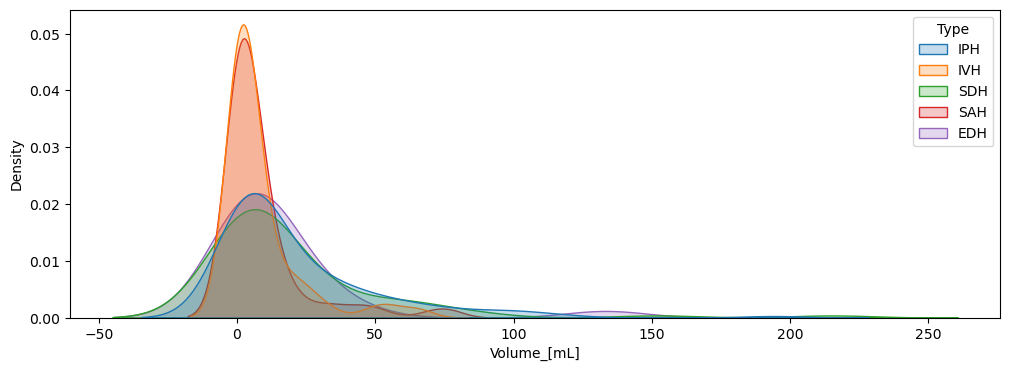

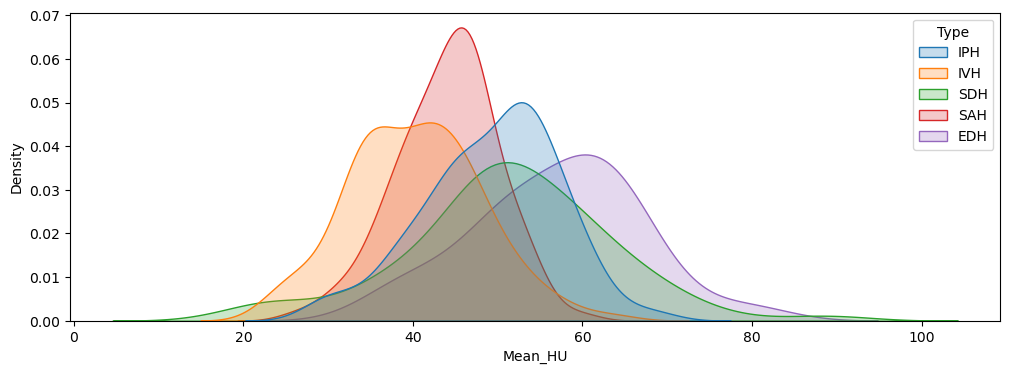

In [4]:

plt.figure(figsize=(12, 4))
sns.kdeplot(data=df, x="Volume_[mL]", hue="Type", legend=True, common_norm=False, fill=True)

plt.figure(figsize=(12, 4))
sns.kdeplot(data=df, x="Mean_HU", hue="Type", legend=True, common_norm=False, fill=True)

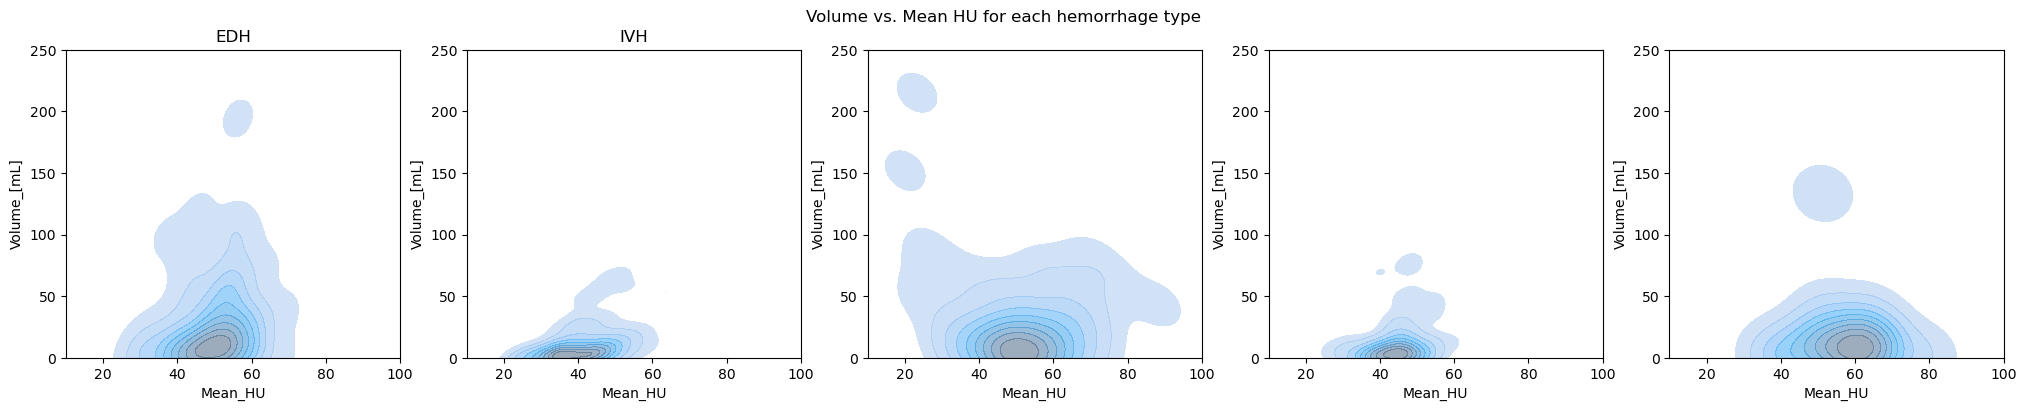

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Volume vs. Mean HU for each hemorrhage type')
axes[0].set_title('IPH')
sns.kdeplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5, thresh=0.02)


axes[1].set_title('IVH')
sns.kdeplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

axes[0].set_title('SDH')
sns.kdeplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

axes[0].set_title('SAH')
sns.kdeplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

axes[0].set_title('EDH')
sns.kdeplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

_ = plt.setp(axes, xlim=(10,100), ylim=(0,250))

### Next, volume with the number of slices:

<Axes: xlabel='Volume_[mL]', ylabel='z_dist'>

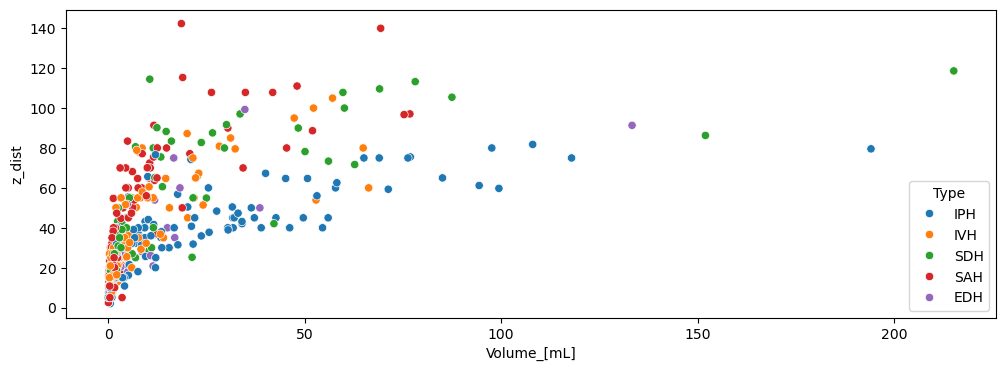

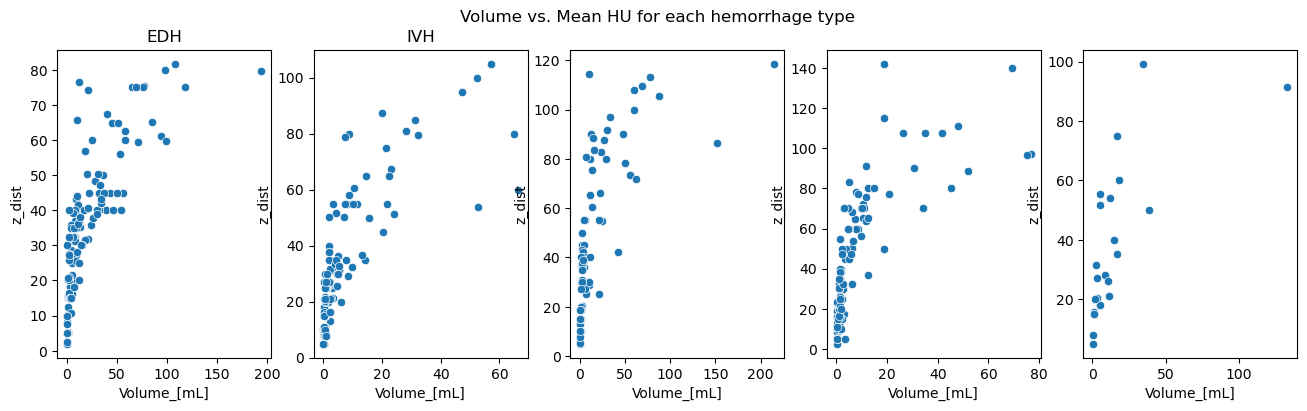

In [5]:
plt.figure(figsize=(12, 4))
sns.scatterplot(data=df, x="Volume_[mL]", y="z_dist", hue="Type", legend=True)

fig, axes = plt.subplots(1, 5, figsize=(16,4))
fig.suptitle('Volume vs. Mean HU for each hemorrhage type')
axes[0].set_title('IPH')
sns.scatterplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Volume_[mL]", y="z_dist")
axes[1].set_title('IVH')
sns.scatterplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Volume_[mL]", y="z_dist")
axes[0].set_title('SDH')
sns.scatterplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Volume_[mL]", y="z_dist")
axes[0].set_title('SAH')
sns.scatterplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Volume_[mL]", y="z_dist")
axes[0].set_title('EDH')
sns.scatterplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Volume_[mL]", y="z_dist")

In [6]:
# initialize empty dataframe
log_coeff = pd.DataFrame(columns=['Type', 'c1', 'c2'])
# statistics
for label_idx in range(1, len(labels)):
    subdf = df.loc[df['Type'] == labels[label_idx]]
    fit = np.polyfit(np.log(subdf['Volume_[mL]']), subdf['z_dist'], 1)
    log_coeff.loc[label_idx - 1] = [labels[label_idx], fit[0], fit[1]]

print(log_coeff)

#df.to_csv('RSNA_BHSD.csv')

grouped = df.groupby('Type')
print('Mean values of each metric by hemorrhage type:')
print(grouped.mean('Mean_HU'))
print(' ')
print('Median values of each metric by hemorrhage type:')
print(grouped.median('Mean_HU'))

df.groupby('Type')[['Mean_HU','Volume_[mL]']].corr()

  Type         c1         c2
0  EDH  13.941807  13.449475
1  IPH   8.706388  18.147618
2  IVH  11.341212  25.434907
3  SAH  17.181158  27.420162
4  SDH  17.738751  17.314196
Mean values of each metric by hemorrhage type:
      Volume_[mL]    Mean_HU  Median_HU        dx        dy        dz  \
Type                                                                    
EDH     15.019148  56.993051  57.695652  0.481212  0.481212  4.748803   
IPH     21.787805  49.260893  49.956693  0.484509  0.484509  5.010305   
IVH      8.313637  40.281126  40.278846  0.490247  0.490247  5.007760   
SAH      8.567363  44.001459  43.463303  0.486865  0.486865  5.000738   
SDH     20.784276  51.263152  50.335714  0.482837  0.482837  4.820745   

      num_slices     z_dist  
Type                         
EDH     7.869565  37.468637  
IPH     6.992126  35.296789  
IVH     6.855769  34.730789  
SAH     8.954128  43.341004  
SDH    10.928571  51.959452  
 
Median values of each metric by hemorrhage type:
      

Mean_HU  Volume_[mL]
Type                                   
EDH  Mean_HU      1.000000    -0.082622
     Volume_[mL] -0.082622     1.000000
IPH  Mean_HU      1.000000     0.232145
     Volume_[mL]  0.232145     1.000000
IVH  Mean_HU      1.000000     0.455174
     Volume_[mL]  0.455174     1.000000
SAH  Mean_HU      1.000000     0.230425
     Volume_[mL]  0.230425     1.000000
SDH  Mean_HU      1.000000    -0.279681
     Volume_[mL] -0.279681     1.000000